<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B06%5D%20-%20Deep%20Learning/MLP_Basico_UCI_BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP básico — Breast Cancer Wisconsin Diagnostic \(UCI\)

Este notebook entrena un **MLP básico** \(red neuronal densa\) sobre un dataset tabular de UCI, sin imágenes y sin Titanic.

Dataset elegido: **Breast Cancer Wisconsin Diagnostic**.

Objetivo: clasificar si una muestra es:

- `0` → Benigno
- `1` → Maligno

La idea del notebook es ir **paso a paso**:

1. Cargar datos tabulares.
2. Entender `X`, `y`, `shape` y clases.
3. Separar train / validación / test.
4. Escalar variables.
5. Crear un MLP sencillo.
6. Entrenar el modelo.
7. Evaluar métricas básicas.
8. Ver predicciones individuales.

No haremos tuning todavía. Es un modelo inicial para entender el flujo completo.

> Dataset UCI: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [66]:
# 0) Instalación de dependencias
# En Google Colab normalmente ya están instaladas.
# Ejecuta esta celda si alguna librería falla.

!pip install tensorflow scikit-learn pandas matplotlib seaborn -q

In [67]:
# 1) Importaciones

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [68]:
# 2) Reproducibilidad
# Fijamos semillas para que los resultados sean parecidos cada vez que ejecutemos el notebook.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism(True)
except Exception:
    pass

print("Semilla fijada en:", SEED)

Semilla fijada en: 42


## 3) Carga del dataset

Usaremos `load_breast_cancer()` de `scikit-learn`, que contiene el dataset **Breast Cancer Wisconsin Diagnostic** de UCI ya preparado para trabajar.

Es un dataset **tabular**, no de imágenes. Cada fila representa una muestra y cada columna representa una característica numérica.

In [69]:
# 3) Cargar datos

data = load_breast_cancer()

X = data.data
# En sklearn: target 0 = malignant, 1 = benign.
# Para que sea más intuitivo en este ejercicio, lo convertimos a:
# 0 = benigno, 1 = maligno

y = 1 - data.target

feature_names = data.feature_names
class_names = np.array(["benigno", "maligno"])

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Número de variables:", X.shape[1])
print("Clases:", class_names)

Shape de X: (569, 30)
Shape de y: (569,)
Número de variables: 30
Clases: ['benigno' 'maligno']


In [70]:
# 4) Convertimos a DataFrame para visualizar mejor

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [71]:
# Información básica del dataset

print("Forma del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nDistribución de la variable objetivo:")
print(df["target"].value_counts())

print("\nDistribución en porcentaje:")
print(df["target"].value_counts(normalize=True) * 100)

Forma del dataset:
(569, 31)

Primeras filas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

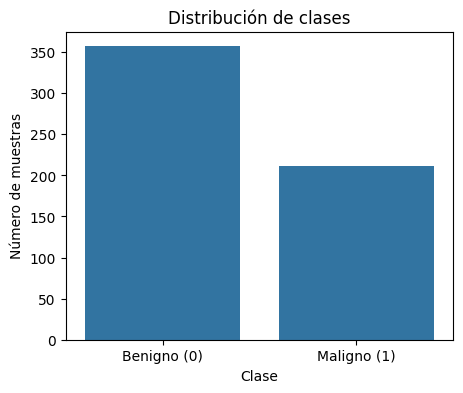

In [72]:
# 6) Gráfico sencillo de la variable objetivo

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="target")
plt.xticks([0, 1], ["Benigno (0)", "Maligno (1)"])
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.show()

## 4) Separación en train, validación y test

Usaremos tres conjuntos:

- **Train**: para entrenar el modelo.
- **Validación**: para vigilar el entrenamiento.
- **Test**: para evaluar al final.

Usamos `stratify=y` para mantener una proporción parecida de clases en cada conjunto.

In [73]:
# 7) Separación en entrenamiento, validación y test

# Primero separamos un 20% para test.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Del 80% restante, sacamos un 20% para validación.
# Resultado aproximado final:
# train = 64%, validación = 16%, test = 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (364, 30)
X_val:   (91, 30)
X_test:  (114, 30)


## 5) Escalado de variables

En redes neuronales es muy importante escalar las variables.

Algunas columnas pueden tener valores grandes y otras valores pequeños. Si no escalamos, el entrenamiento puede ser más difícil.

Usaremos `StandardScaler`:

z = (x - μ) / σ

x  = valor original
μ  = media de esa columna
σ  = desviación típica de esa columna
z  = valor escalado


Importante:

- El scaler se **ajusta solo con train**. fit_transform
- Después se aplica a validación y test. transform

Esto evita fuga de información del test hacia el entrenamiento.

radius_mean       → valores entre 6 y 30

area_mean         → valores entre 140 y 2500

smoothness_mean   → valores entre 0.05 y 0.16

La red neurona trabaja multiplicando entradas por pesos, eso puede hacer que un valor grande decante el entrenamiento

In [74]:
# 8) Escalado

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Media aproximada de X_train_scaled:", X_train_scaled.mean().round(4))
print("Desviación típica aproximada:", X_train_scaled.std().round(4))

Media aproximada de X_train_scaled: 0.0
Desviación típica aproximada: 1.0


## 6) Construcción del MLP básico

Un **MLP** \(Multi-Layer Perceptron\) es una red neuronal formada por capas densas.

Nuestra arquitectura será sencilla:

```text
Entrada: 30 variables
↓
Dense(16, relu)
↓
Dropout(0.2)
↓
Dense(8, relu)
↓
Dense(1, sigmoid)
```

¿Por qué la última capa tiene 1 neurona con `sigmoid`?

Porque es un problema de **clasificación binaria**:

- Salida cercana a 0 → benigno
- Salida cercana a 1 → maligno

In [75]:
# 10) Definir el modelo

n_features = X_train_scaled.shape[1]
model = keras.Sequential([
    # Capa de entrada explícita: cada muestra tiene 30 variables
    layers.Input(shape=(n_features,)),

    # Primera capa oculta
    layers.Dense(16, activation="relu", name="dense_16"),

    # Dropout: apaga aleatoriamente el 20% de activaciones durante entrenamiento
    # Ayuda a reducir el sobreajuste.
    layers.Dropout(0.2, name="dropout_20"),

    # Segunda capa oculta
    layers.Dense(8, activation="relu", name="dense_8"),

    # Capa de salida binaria
    layers.Dense(1, activation="sigmoid", name="salida_sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_sigmoid (Dense)          │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### ¿Qué significan los parámetros?

En una capa `Dense`, los parámetros son:

```text
parámetros = entradas × neuronas + biases
```

Por ejemplo, si entran 30 variables y la capa tiene 16 neuronas:

```text
30 × 16 + 16 = 496 parámetros
```

Los parámetros son los valores que el modelo aprende durante el entrenamiento.

In [76]:
# 11) Compilación del modelo

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

print("Modelo compilado.")

Modelo compilado.


## 7) Entrenamiento

Entrenamos el modelo con:

- `epochs=50`: máximo de 50 pasadas completas por el dataset de entrenamiento.
- `batch_size=32`: actualiza pesos cada 32 muestras.
- `validation_data`: permite ver cómo evoluciona el modelo en validación.
- `EarlyStopping`: detiene el entrenamiento si la validación deja de mejorar.

Esto es una buena práctica básica para no entrenar de más.

In [77]:
# 12) EarlyStopping básico

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# 13) Entrenamiento

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.3791 - auc: 0.4184 - loss: 0.8957 - precision: 0.3757 - recall: 1.0000 - val_accuracy: 0.3626 - val_auc: 0.5753 - val_loss: 0.7659 - val_precision: 0.3667 - val_recall: 0.9706
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3791 - auc: 0.6050 - loss: 0.7923 - precision: 0.3743 - recall: 0.9853 - val_accuracy: 0.3626 - val_auc: 0.7299 - val_loss: 0.7003 - val_precision: 0.3667 - val_recall: 0.9706
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4093 - auc: 0.7632 - loss: 0.7062 - precision: 0.3868 - recall: 0.9926 - val_accuracy: 0.4505 - val_auc: 0.8514 - val_loss: 0.6547 - val_precision: 0.4000 - val_recall: 0.9412
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4505 - auc: 0.8229 - loss: 0.6645 - precision: 0.4024 - recall: 0.9706 - val_accuracy: 0.5275 - val_auc: 0.9123 - val_loss: 0.6183 - val_precision: 0.4384 - val_recall: 0.9412
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━

In [78]:
# 14) Historial de entrenamiento

history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.379121,0.418392,0.895728,0.375691,1.000000,0.362637,0.575335,0.765926,0.366667,0.970588
1,0.379121,0.604973,0.792300,0.374302,0.985294,0.362637,0.729876,0.700301,0.366667,0.970588
2,0.409341,0.763206,0.706218,0.386819,0.992647,0.450549,0.851393,0.654672,0.400000,0.941176
3,0.450549,0.822901,0.664501,0.402439,0.970588,0.527473,0.912281,0.618276,0.438356,0.941176
4,0.541209,0.876016,0.625182,0.447099,0.963235,0.681319,0.937822,0.587949,0.540984,0.970588


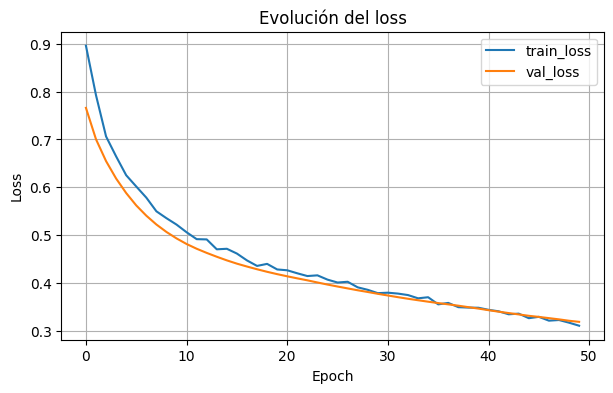

In [79]:
# 15) Curvas de loss

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Evolución del loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

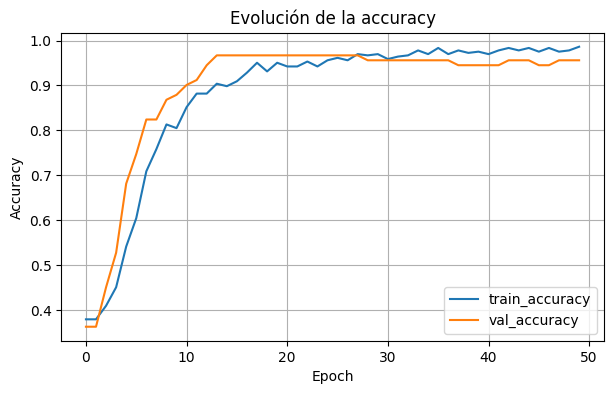

In [80]:
# 16) Curvas de accuracy

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 8) Evaluación final en test

Ahora evaluamos el modelo en datos que no ha usado ni para entrenar ni para validar.

In [81]:
# 17) Evaluación con model.evaluate

test_results = model.evaluate(X_test_scaled, y_test, verbose=0)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

loss: 0.3266
compile_metrics: 0.9825


In [82]:
# 18) Predicciones en test

# El modelo devuelve probabilidades entre 0 y 1
y_pred_prob = model.predict(X_test_scaled)

# Convertimos las probabilidades en clases:
# si la probabilidad es >= 0.5, clase 1
# si la probabilidad es < 0.5, clase 0
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Primeras probabilidades predichas:")
print(y_pred_prob[:10])

print("\nPrimeras clases predichas:")
print(y_pred[:10].ravel())

print("\nPrimeras clases reales:")
print(y_test[:10])

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Primeras probabilidades predichas:
[[0.3639161]
 [1.       ]
 [0.3639161]
 [0.5388898]
 [0.3639161]
 [0.3639161]
 [0.8980253]
 [0.3639161]
 [0.3639161]
 [0.3639161]]

Primeras clases predichas:
[0 1 0 1 0 0 1 0 0 0]

Primeras clases reales:
[0 1 0 1 0 0 1 0 0 0]


In [83]:
# 19) Métricas manuales

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("AUC      :", round(auc, 4))

Accuracy : 0.9825
Precision: 0.9762
Recall   : 0.9762
F1-score : 0.9762
AUC      : 0.9861


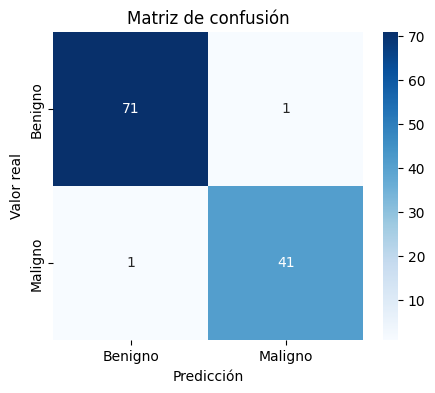

In [84]:
# 20) Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [85]:
# 21) Reporte de clasificación

print(classification_report(
    y_test,
    y_pred,
    target_names=["Benigno (0)", "Maligno (1)"]
))

              precision    recall  f1-score   support

 Benigno (0)       0.99      0.99      0.99        72
 Maligno (1)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 9) Predicción de ejemplos individuales

Vamos a crear una pequeña tabla con ejemplos del test:

- clase real
- probabilidad predicha de maligno
- clase predicha

In [86]:
# 22) Tabla de predicciones individuales

resultados = pd.DataFrame({
    "real": y_test.ravel(),
    "prob_clase_1": y_pred_prob.ravel(),
    "prediccion": y_pred.ravel()
})

resultados.head(10)

,real,prob_clase_1,prediccion
0,0,0.363916,0
1,1,1.000000,1
2,0,0.363916,0
3,1,0.538890,1
4,0,0.363916,0
5,0,0.363916,0
6,1,0.898025,1
7,0,0.363916,0
8,0,0.363916,0
9,0,0.363916,0


## 10) Conclusiones

En este notebook has visto el flujo básico de un MLP para datos tabulares:

```text
Datos tabulares
↓
Train / validación / test
↓
Escalado
↓
MLP básico
↓
Entrenamiento
↓
Evaluación
↓
Predicciones
```

Ideas clave:

- Un MLP recibe vectores de variables, no imágenes 2D directamente.
- En clasificación binaria usamos una salida con `sigmoid`.
- Para `sigmoid`, la loss habitual es `binary_crossentropy`.
- El `batch_size` indica cada cuántas muestras se actualizan los pesos.
- Las métricas de test se miran al final, no durante el diseño del modelo.